# Exploratory Data Analysis

## Содержание

- [Обзор датасета](#Обзор-датасета)
- [Загрузка данных](#Загрузка-данных)
- [SeriousDlqin2yrs](#SeriousDlqin2yrs)
- [RevolvingUtilizationOfUnsecuredLines](#RevolvingUtilizationOfUnsecuredLines)
- [age](#age)
- [DebtRatio](#DebtRatio)
- [MonthlyIncome](#MonthlyIncome)
- [Выводы](#Выводы)

## Обзор датасета

Целевая переменная:

- `SeriousDlqin2yrs` (0 или 1) — имел ли заемщик серьезную просрочку (90 дней или более) в течение последних 2 лет.

Признаки:

- `age` (целое число) — возраст заемщика в годах.

- `MonthlyIncome` (вещественное число) — ежемесячный доход заемщика.

- `NumberOfDependents` (целое число) — количество иждивенцев в семье, не включая самого заемщика (супруг, дети и др.).

- `RevolvingUtilizationOfUnsecuredLines` (процент) — коэффициент использования необеспеченных кредитных линий. Рассчитывается как общий баланс по кредитным картам и персональным кредитным линиям (за исключением недвижимости и рассрочек, таких как автокредиты), деленный на сумму кредитных лимитов.

- `DebtRatio` (процент) — отношение долговой нагрузки к доходу. Включает ежемесячные платежи по долгам, алименты и расходы на жизнь, деленные на ежемесячный доход.

- `NumberOfOpenCreditLinesAndLoans` (целое число) — общее количество открытых кредитов (например, автокредиты или ипотека) и кредитных линий (например, кредитные карты).

- `NumberRealEstateLoansOrLines` (целое число) — количество ипотечных кредитов и кредитов под залог недвижимости, включая кредитные линии под залог собственного капитала.

- `NumberOfTime3059DaysPastDueNotWorse` (целое число) — количество случаев, когда заемщик имел просрочку от 30 до 59 дней (но не хуже) за последние 2 года.

- `NumberOfTime60-89DaysPastDueNotWorse` (целое число) — количество случаев, когда заемщик имел просрочку от 60 до 89 дней (но не хуже) за последние 2 года.

- `NumberOfTimes90DaysLate` (целое число) — количество случаев, когда заемщик имел просрочку 90 дней или более.

## Загрузка данных

In [132]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

seed = 42
np.random.seed(seed)

In [4]:
train = pd.read_csv('../data/raw/GiveMeSomeCredit/cs-training.csv', index_col='Unnamed: 0')

X_train = train.drop(columns=['SeriousDlqin2yrs'])
y_train = train['SeriousDlqin2yrs']

## SeriousDlqin2yrs

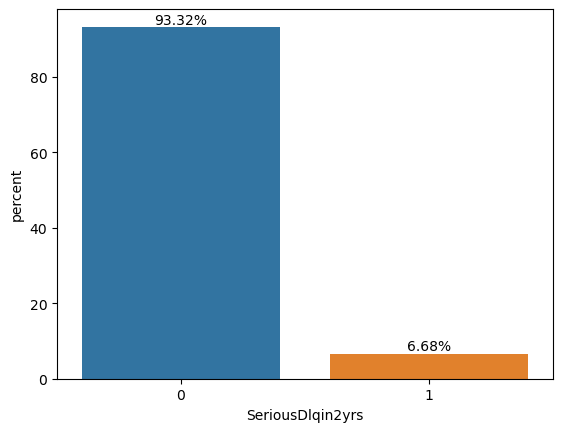

In [5]:
target_dist = (train.SeriousDlqin2yrs
                    .value_counts(normalize=True)
                    .mul(100)
                    .rename('percent')
                    .reset_index())

ax = sns.barplot(data=target_dist, x='SeriousDlqin2yrs', y='percent', hue='SeriousDlqin2yrs', legend=False);
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', fontsize=10)

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: fl

Имеем неполный набор `MonthlyIncome` и `NumberOfDependents`

In [7]:
print(f"Пропусков в MonthlyIncome:      {train.MonthlyIncome.isna().mean() * 100:.2f}%")
print(f"Пропусков в NumberOfDependents: {train.NumberOfDependents.isna().mean() * 100:.2f}%")

Пропусков в MonthlyIncome:      19.82%
Пропусков в NumberOfDependents: 2.62%


In [8]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


## RevolvingUtilizationOfUnsecuredLines

In [9]:
train['RevolvingUtilizationOfUnsecuredLines'].describe(percentiles=[.25, .5, .75, .95, .99, .997])

count    150000.000000
mean          6.048438
std         249.755371
min           0.000000
25%           0.029867
50%           0.154181
75%           0.559046
95%           1.000000
99%           1.092956
99.7%         1.760802
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [10]:
RUUL_bins = np.concatenate((np.linspace(0, 1, 11),
                            [1.5, 2, 100],
                            np.arange(1000, train['RevolvingUtilizationOfUnsecuredLines'].max()+1, 1000),
                            [train['RevolvingUtilizationOfUnsecuredLines'].max()]))

train['RUUL_bin'] = pd.cut(train['RevolvingUtilizationOfUnsecuredLines'],
                           bins=RUUL_bins,
                           duplicates='drop',
                           include_lowest=True)

RUUL_stats = train.groupby('RUUL_bin').agg(DefaultRisk=('SeriousDlqin2yrs', 'mean'))

RUUL_stats['NumberOfClients'] = train['RUUL_bin'].value_counts()
RUUL_stats

,DefaultRisk,NumberOfClients
RUUL_bin,,
"(-0.001, 0.1]",0.018104,64404
"(0.1, 0.2]",0.027795,17305
"(0.2, 0.3]",0.037054,11173
"(0.3, 0.4]",0.052704,8671
"(0.4, 0.5]",0.065512,7159
...,...,...
"(46000.0, 47000.0]",NaN,0
"(47000.0, 48000.0]",NaN,0
"(48000.0, 49000.0]",NaN,0


## age

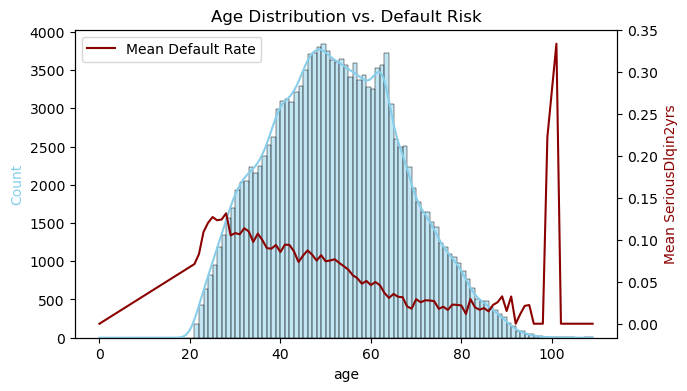

In [11]:
fig, ax1 = plt.subplots(figsize=(7, 4))

sns.histplot(data=train, x='age', kde=True, ax=ax1, color='skyblue', bins=sorted(train.age.unique()))
ax1.set_ylabel('Count', color='skyblue')

ax2 = ax1.twinx()

age_risk = train.groupby('age')['SeriousDlqin2yrs'].mean()

sns.lineplot(data=age_risk, ax=ax2, color='darkred', label='Mean Default Rate')
ax2.set_ylabel('Mean SeriousDlqin2yrs', color='darkred')

plt.title('Age Distribution vs. Default Risk')
plt.show()

In [12]:
age_stats = train.groupby('age').agg(count=('age', 'size'), DefaultRisk=('SeriousDlqin2yrs', 'mean')).reset_index()

age_stats.loc[age_stats.age >= 90]

,age,count,DefaultRisk
70,90,198,0.015152
71,91,154,0.032468
72,92,93,0.000000
73,93,87,0.011494
74,94,47,0.021277
75,95,45,0.022222
76,96,18,0.000000
77,97,17,0.000000
78,98,6,0.000000
79,99,9,0.222222


Пик риска при возрасте около 100 лет, вероятно, обусловлен малой численностью респондентов и случайным всплеском в данных.

In [13]:
train.groupby('age').agg(DefaultRisk=('SeriousDlqin2yrs', 'mean'))

,DefaultRisk
age,
0,0.000000
21,0.071038
22,0.082949
23,0.109204
24,0.120098
...,...
102,0.000000
103,0.000000
105,0.000000


## DebtRatio

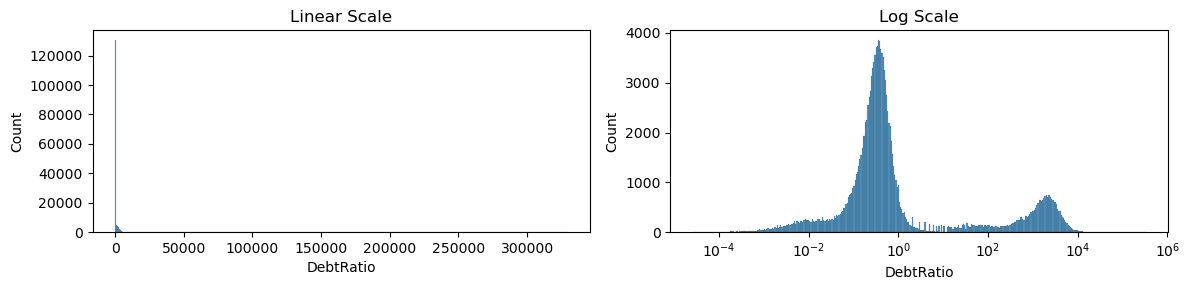

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(12, 3))

sns.histplot(data=train, x='DebtRatio', bins=500, ax=axs[0]);
sns.histplot(data=train, x='DebtRatio', log_scale=True, ax=axs[1]);

axs[1].set_title('Log Scale')
axs[0].set_title('Linear Scale')

plt.tight_layout()
plt.show()

In [15]:
train['DebtRatio_q_bin'] = pd.qcut(train.DebtRatio, q=20, duplicates='drop')
train.groupby('DebtRatio_q_bin').agg(Count=('DebtRatio', 'size'),
                                     MonthlyIncome_mean=('MonthlyIncome', 'mean'),
                                     DefaultRisk=('SeriousDlqin2yrs', 'mean'))

,Count,MonthlyIncome_mean,DefaultRisk
DebtRatio_q_bin,,,
"(-0.001, 0.00433]",7501,7612.988774,0.058126
"(0.00433, 0.0309]",7499,7258.774637,0.049473
"(0.0309, 0.0864]",7500,7432.922400,0.070800
"(0.0864, 0.134]",7500,7412.272933,0.065600
"(0.134, 0.175]",7500,7263.369467,0.060133
"(0.175, 0.214]",7500,7664.277467,0.060533
"(0.214, 0.251]",7500,7601.900267,0.053333
"(0.251, 0.287]",7500,7642.118400,0.054800
"(0.287, 0.325]",7500,7431.823600,0.052667


За пиком риска на интервале (0.868, 4.0] следует падение заработной платы почти до нуля

In [16]:
train['DebtRatio_bin'] = pd.cut(train.DebtRatio, duplicates='drop', bins=np.arange(0, 329665, 2), include_lowest=True)
train['DebtRatio_bin_left'] = train.DebtRatio_bin.map(lambda x: x.left)
train['MonthlyIncome_mean_DR_bin'] = train.groupby('DebtRatio_bin_left').MonthlyIncome.transform('mean')

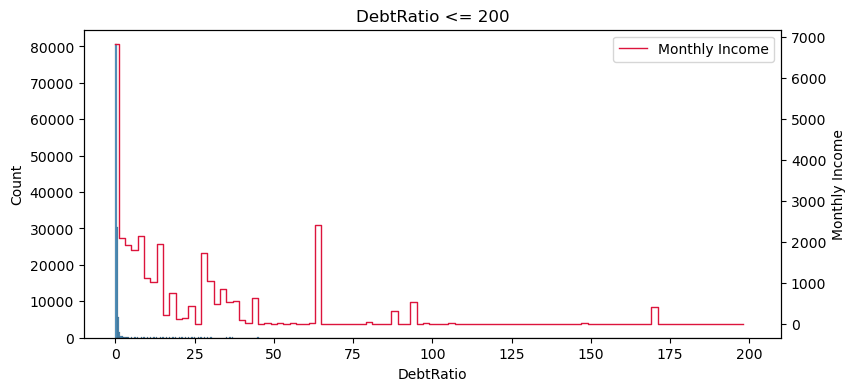

In [17]:
fig, ax1 = plt.subplots(figsize=(9, 4))

sns.histplot(data=train.loc[train.DebtRatio.le(200)], x='DebtRatio', bins=500, ax=ax1, label='Count')

ax2 = ax1.twinx()

sns.lineplot(
    data=train.loc[train.DebtRatio.le(200)], 
    x='DebtRatio_bin_left', 
    y='MonthlyIncome_mean_DR_bin', 
    errorbar=None,
    drawstyle='steps-mid',
    color='crimson',
    linewidth=1,
    ax=ax2,
    label='Monthly Income'
)

ax1.grid(False)
ax2.set_title('DebtRatio <= 200');
ax2.set_ylabel('Monthly Income');

In [18]:
train.loc[train.DebtRatio.between(50, 75) & train.MonthlyIncome.ge(100)]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RUUL_bin,DebtRatio_q_bin,DebtRatio_bin,DebtRatio_bin_left,MonthlyIncome_mean_DR_bin
55487,0,0.228582,65,0,65.712209,7223.0,14,0,0,0,0.0,"(0.2, 0.3]","(4.0, 269.15]","(64.0, 66.0]",64.0,2407.666667
61020,0,0.068091,72,0,62.138614,100.0,17,0,2,0,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(62.0, 64.0]",62.0,16.142857


Пик около `DebtRatio ≈ 65` обусловлен наличием респондента с высокой (7223) зарплатой 

In [19]:
train['DebtRatio_bin'] = pd.cut(train.DebtRatio,
                                bins=np.concatenate([[0, 0.5, 1, 2, 3.5, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50],
                                                    np.arange(100, 4001, 100),
                                                    [train.DebtRatio.max()]]),
                                duplicates='drop')

train.groupby('DebtRatio_bin').agg(Count=('DebtRatio', 'size'),
                                     MonthlyIncome_mean=('MonthlyIncome', 'mean'),
                                     DefaultRisk=('SeriousDlqin2yrs', 'mean'))


,Count,MonthlyIncome_mean,DefaultRisk
DebtRatio_bin,,,
"(0.0, 0.5]",89595,7385.688922,0.059323
"(0.5, 1.0]",21155,5445.323819,0.098322
"(1.0, 2.0]",4092,3470.462106,0.131720
"(2.0, 3.5]",883,2121.987637,0.087203
"(3.5, 5.0]",516,2027.171946,0.063953
"(5.0, 10.0]",769,1832.902439,0.042913
"(10.0, 15.0]",577,1258.951807,0.034662
"(15.0, 20.0]",438,865.333333,0.043379
"(20.0, 25.0]",415,263.828571,0.067470


In [20]:
train.loc[train.DebtRatio.gt(50) & (train.MonthlyIncome.gt(1)), ['MonthlyIncome', 'DebtRatio']]

,MonthlyIncome,DebtRatio
984,21.0,106.272727
1616,2.0,364.000000
5856,25.0,149.423077
10405,56.0,57.000000
14810,10.0,206.727273
17831,2.0,107.333333
37907,55.0,52.017857
40083,4.0,93.000000
43785,2.0,450.333333
55065,9.0,141.400000


In [21]:
threshold = 50

DR_pct_gt_60   = 100 * (1 - train.DebtRatio.rank(pct=True).loc[train.DebtRatio == threshold].iloc[0])
DR_MonInc_le_1 = 100 * (train.loc[train.DebtRatio.gt(threshold) & (train.MonthlyIncome.le(1) | train.MonthlyIncome.isna()), 'MonthlyIncome'].isna().shape[0] / train.shape[0])

print(f"Процент клиентов с DebtRatio > {threshold}: {DR_pct_gt_60:.2f}%")
print(f"Из них с доходом <= 1 или NaN: {100 * DR_MonInc_le_1 / DR_pct_gt_60:.2f}%")

Процент клиентов с DebtRatio > 50: 17.30%
Из них с доходом <= 1 или NaN: 99.82%


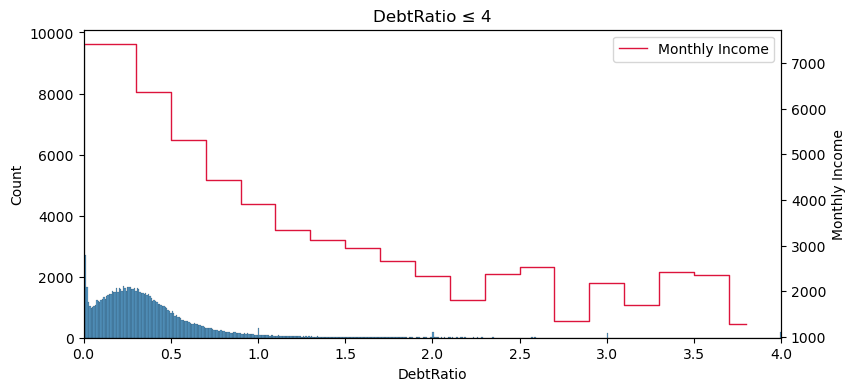

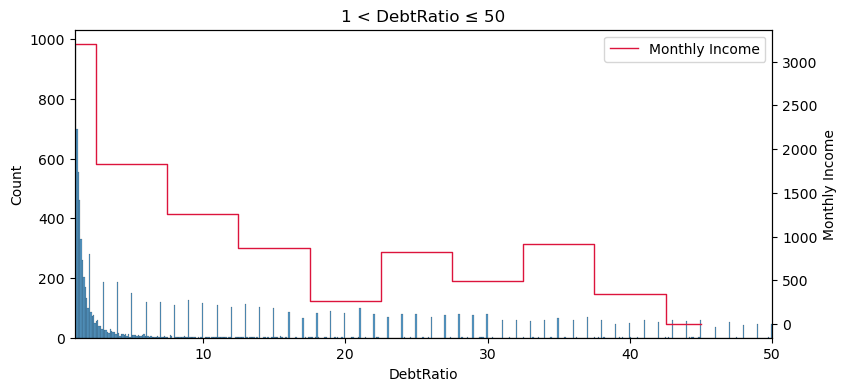

In [22]:
def plot_debt_ratio_vs_income(
    df: pd.DataFrame,
    *,
    mask: pd.Series,
    bin_step: float,
    title: str,
    hist_bins: int = 500,
    xlim: tuple[float, float] | None = None,
    figsize: tuple[int, int] = (9, 4),
):
    d = df.loc[mask, ["DebtRatio", "MonthlyIncome"]].copy()

    max_edge = df["DebtRatio"].max()
    edges = np.r_[np.arange(0, 100, bin_step), max_edge]

    bins = pd.cut(d["DebtRatio"], bins=edges, include_lowest=True, duplicates="drop")

    mean_income = (
        d.groupby(bins, observed=True)["MonthlyIncome"]
        .mean()
        .rename("MonthlyIncome_mean")
        .reset_index()
    )

    mean_income["DebtRatio_bin_left"] = mean_income[bins.name].apply(lambda iv: iv.left)

    fig, ax1 = plt.subplots(figsize=figsize)

    sns.histplot(
        data=d,
        x="DebtRatio",
        bins=hist_bins,
        ax=ax1,
        label="Count",
    )

    ax2 = ax1.twinx()
    sns.lineplot(
        data=mean_income,
        x="DebtRatio_bin_left",
        y="MonthlyIncome_mean",
        errorbar=None,
        drawstyle="steps-mid",
        color="crimson",
        linewidth=1,
        ax=ax2,
        label="Monthly Income",
    )

    if xlim is not None:
        ax1.set_xlim(*xlim)

    ax1.grid(False)
    ax2.set_title(title)
    ax2.set_ylabel("Monthly Income")
    plt.show()


plot_debt_ratio_vs_income(
    train,
    mask=train["DebtRatio"].le(4),
    bin_step=0.2,
    title="DebtRatio ≤ 4",
    xlim=(0, 4),
)

plot_debt_ratio_vs_income(
    train,
    mask=train["DebtRatio"].gt(1) & train["DebtRatio"].le(50),
    bin_step=5,
    title="1 < DebtRatio ≤ 50",
    xlim=(1, 50),
)

In [23]:
median_income = 10000#train.MonthlyIncome.median()
print(f"Медианная зарплата: {median_income:.2f}")

print()

rich_pct_1_25 = train.loc[train.DebtRatio.between(1, 25) & train.MonthlyIncome.gt(median_income), 'DebtRatio'].count() / train.loc[train.DebtRatio.between(1, 25), 'DebtRatio'].count()
print(f"Зп больше медианы на DebtRatio (1, 25]: {100 * rich_pct_1_25:.2f}%")
nowork_pct_1_25 = train.loc[train.DebtRatio.between(1, 25) & (train.MonthlyIncome.le(1) | train.MonthlyIncome.isna()), 'DebtRatio'].shape[0] / train.loc[train.DebtRatio.between(1, 25), 'DebtRatio'].count()
print(f"Зп <= 1 или NaN на DebtRatio (1, 25]: {100 * nowork_pct_1_25:.2f}%")

print()

rich_pct_25_50 = train.loc[train.DebtRatio.between(25, 50) & train.MonthlyIncome.gt(median_income), 'DebtRatio'].count() / train.loc[train.DebtRatio.between(25, 50), 'DebtRatio'].count()
print(f"Зп больше медианы на DebtRatio (25, 50]: {100 * rich_pct_25_50:.2f}%")
nowork_pct_25_50 = train.loc[train.DebtRatio.between(25, 50) & (train.MonthlyIncome.le(1) | train.MonthlyIncome.isna()), 'DebtRatio'].shape[0] / train.loc[train.DebtRatio.between(25, 50), 'DebtRatio'].count()
print(f"Зп <= 1 или NaN на DebtRatio (25, 50]: {100 * nowork_pct_25_50:.2f}%")

train.loc[train.DebtRatio.between(20, 40) & train.MonthlyIncome.ge(2000)]

Медианная зарплата: 10000.00

Зп больше медианы на DebtRatio (1, 25]: 1.64%
Зп <= 1 или NaN на DebtRatio (1, 25]: 35.38%

Зп больше медианы на DebtRatio (25, 50]: 0.19%
Зп <= 1 или NaN на DebtRatio (25, 50]: 98.68%


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,RUUL_bin,DebtRatio_q_bin,DebtRatio_bin,DebtRatio_bin_left,MonthlyIncome_mean_DR_bin
34110,0,0.000000,63,5,30.326467,8300.0,16,1,2,1,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(30.0, 35.0]",30.0,1037.625000
50217,0,0.340559,63,0,28.171455,15000.0,14,0,4,0,1.0,"(0.3, 0.4]","(4.0, 269.15]","(25.0, 30.0]",28.0,1732.722222
59910,1,0.698978,48,0,35.440782,13500.0,11,0,0,0,1.0,"(0.6, 0.7]","(4.0, 269.15]","(35.0, 40.0]",34.0,843.875000
60048,1,0.000000,57,0,24.189647,6200.0,6,0,0,0,1.0,"(-0.001, 0.1]","(4.0, 269.15]","(20.0, 25.0]",24.0,429.400000
77259,1,0.815674,50,2,29.612885,3600.0,16,0,0,0,0.0,"(0.8, 0.9]","(4.0, 269.15]","(25.0, 30.0]",28.0,1732.722222
80264,0,0.161309,31,1,33.610994,6166.0,14,0,2,0,2.0,"(0.1, 0.2]","(4.0, 269.15]","(30.0, 35.0]",32.0,482.307692
91948,0,0.161541,68,0,37.823700,2750.0,8,0,4,0,0.0,"(0.1, 0.2]","(4.0, 269.15]","(35.0, 40.0]",36.0,519.000000
96900,0,0.004480,74,0,38.201133,6000.0,6,0,0,0,0.0,"(-0.001, 0.1]","(4.0, 269.15]","(35.0, 40.0]",38.0,555.272727
139095,0,0.514390,44,2,28.632287,12487.0,9,0,1,1,3.0,"(0.5, 0.6]","(4.0, 269.15]","(25.0, 30.0]",28.0,1732.722222


Доход <= 1 у 99.82% клиентов с `DebtRatio > 50` и у всех клиентов с `DebtRatio >= 451`

In [24]:
DR_50_pct  = train['DebtRatio'].rank(pct=True).loc[train.DebtRatio.eq(50)].iloc[0]
DR_451_pct = train['DebtRatio'].rank(pct=True).loc[train.DebtRatio.eq(451)].iloc[0]
print(f"Всего {100 * (1 - DR_50_pct):.2f}% пользователей с DebtRatio > 50")
print(f"Всего {100 * (1 - DR_451_pct):.2f}% пользователей с DebtRatio > 451")

Всего 17.30% пользователей с DebtRatio > 50
Всего 14.01% пользователей с DebtRatio > 451


## MonthlyIncome

In [25]:
missing_income = train.MonthlyIncome.isna().sum()
print(f"Количество пропусков: {missing_income} ({100 * missing_income / train.shape[0]:.2f}%)\n")

Количество пропусков: 29731 (19.82%)

Пропусков при DebtRatio > 50:  24138 (81.19%)
Пропусков при DebtRatio > 451: 19674 (66.17%)


count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

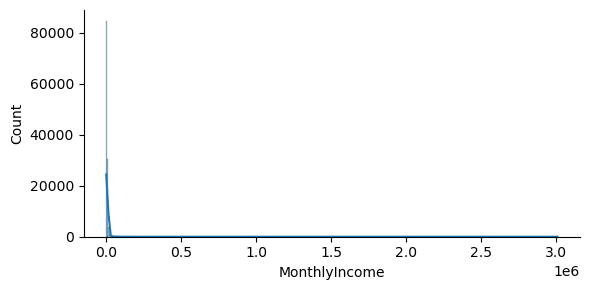

In [100]:
sns.displot(data=train, x='MonthlyIncome', bins=400, kde=True, height=3, aspect=2);
train.MonthlyIncome.describe()

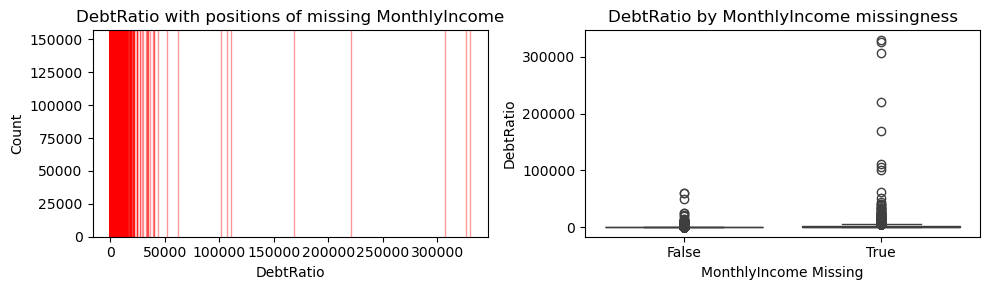

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

df = train[train.DebtRatio.notna()]

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

sns.histplot(df.DebtRatio, bins=50, kde=False, color='lightblue', ax=axes[0])

missing_DR = df.loc[df.MonthlyIncome.isna(), 'DebtRatio']
for x in missing_DR:
    axes[0].axvline(x=x, color='red', alpha=0.4, linewidth=1)
axes[0].set_xlabel('DebtRatio')
axes[0].set_ylabel('Count')
axes[0].set_title('DebtRatio with positions of missing MonthlyIncome')

df_plot = df.copy()
df_plot['Income_Missing'] = df_plot.MonthlyIncome.isna()

sns.boxplot(data=df_plot, y='DebtRatio', x='Income_Missing', ax=axes[1])
axes[1].set_xlabel('MonthlyIncome Missing')
axes[1].set_ylabel('DebtRatio')
axes[1].set_title('DebtRatio by MonthlyIncome missingness')

plt.tight_layout()
plt.show()

In [40]:
DR_max_income_notna = train.loc[train.MonthlyIncome.notna(), 'DebtRatio'].max()
print(f"Максимальный DebtRatio с MonthlyIncome notna: {DR_max_income_notna}")

Максимальный DebtRatio с MonthlyIncome notna: 61106.5


In [99]:
print(f"Клиенты с DebtRatio > {DR_max_income_notna}:")
train.loc[train.DebtRatio.gt(DR_max_income_notna), 'SeriousDlqin2yrs']

Клиенты с DebtRatio > 61106.5:


4855      0
7514      0
36601     0
58901     0
60153     0
66786     0
69846     0
103042    0
127048    0
Name: SeriousDlqin2yrs, dtype: int64

Мода DebtRatio с MonthlyIncome.notna(): 0.34
Мода DebtRatio с MonthlyIncome.isna():  1995.73
Мода DebtRatio с MonthlyIncome == 0:    1500.28


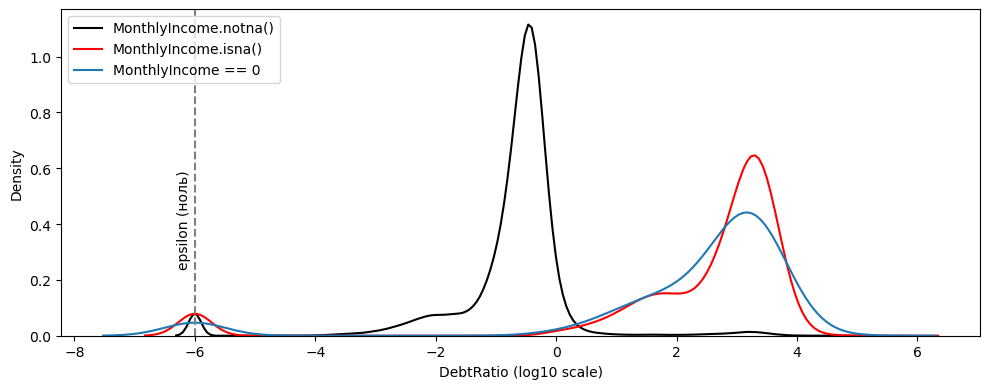

In [247]:
x_notna = train.loc[train.MonthlyIncome.notna(), 'DebtRatio']
x_isna  = train.loc[train.MonthlyIncome.isna(),  'DebtRatio']
x_zero  = train.loc[train.MonthlyIncome.eq(0),   'DebtRatio']

def get_mode(ax, idx):
    xs = ax.get_lines()[idx].get_xdata()
    ys = ax.get_lines()[idx].get_ydata()
    return xs[np.argmax(ys)]

fig, ax = plt.subplots(figsize=(10, 4))

epsilon = 1e-6
sns.kdeplot(x=np.log10(x_notna + epsilon), ax=ax, color='black', label='MonthlyIncome.notna()')
sns.kdeplot(x=np.log10(x_isna  + epsilon), ax=ax, color='red',   label='MonthlyIncome.isna()')
sns.kdeplot(x=np.log10(x_zero  + epsilon), ax=ax,                label='MonthlyIncome == 0')

plt.axvline(x=np.log10(epsilon), color='gray', linestyle='--')
plt.text(np.log10(epsilon)-0.3, 0.25, 'epsilon (ноль)', rotation=90)

print(f"Мода DebtRatio с MonthlyIncome.notna(): {10 ** get_mode(ax, 0):.2f}")
print(f"Мода DebtRatio с MonthlyIncome.isna():  {10 ** get_mode(ax, 1):.2f}")
print(f"Мода DebtRatio с MonthlyIncome == 0:    {10 ** get_mode(ax, 2):.2f}")

ax.legend(loc='upper left')
ax.set_xlabel('DebtRatio (log10 scale)')
plt.tight_layout()
plt.show()

In [119]:
missing_income_DR_gt_1   = train.loc[train.DebtRatio.gt(1)   & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_10  = train.loc[train.DebtRatio.gt(10)  & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_50  = train.loc[train.DebtRatio.gt(50)  & train.MonthlyIncome.isna(), 'DebtRatio'].count()
missing_income_DR_gt_451 = train.loc[train.DebtRatio.gt(451) & train.MonthlyIncome.isna(), 'DebtRatio'].count()

print(f"Пропусков при DebtRatio > 1:   {missing_income_DR_gt_1} ({100 * missing_income_DR_gt_1 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 10:  {missing_income_DR_gt_10} ({100 * missing_income_DR_gt_10 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 50:  {missing_income_DR_gt_50} ({100 * missing_income_DR_gt_50 / missing_income:.2f}%)")
print(f"Пропусков при DebtRatio > 451: {missing_income_DR_gt_451} ({100 * missing_income_DR_gt_451 / missing_income:.2f}%)")

Пропусков при DebtRatio > 1:   27904 (93.85%)
Пропусков при DebtRatio > 10:  26771 (90.04%)
Пропусков при DebtRatio > 50:  24138 (81.19%)
Пропусков при DebtRatio > 451: 19674 (66.17%)


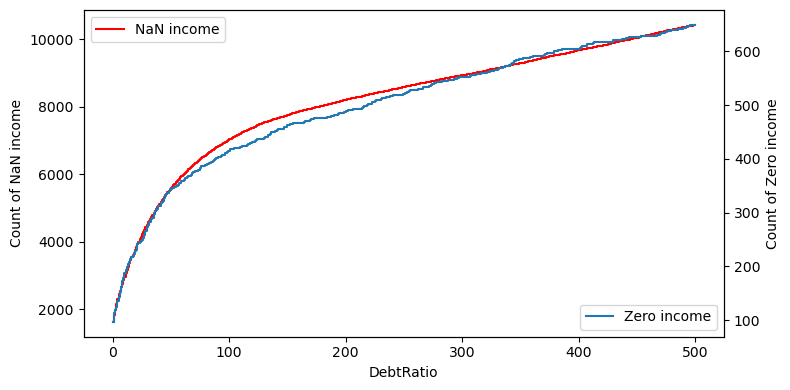

In [296]:
missing_income = train.loc[train.MonthlyIncome.isna() & train.DebtRatio.between(0, 500), 'DebtRatio']
zero_income = train.loc[train.MonthlyIncome.eq(0) & train.DebtRatio.between(0, 500), 'DebtRatio']

fig, ax1 = plt.subplots(figsize=(8, 4))

sns.histplot(missing_income, bins=500, cumulative=1, element="step", color='red', fill=False, ax=ax1, label='NaN income')
plt.ylabel('Count of NaN income')
ax1.legend()

ax2=ax1.twinx()

sns.histplot(zero_income, bins=500, cumulative=1, element="step", fill=False, ax=ax2, label='Zero income')
plt.ylabel('Count of Zero income')
ax2.legend(loc='lower right')

plt.tight_layout()
plt.show()

## `MonthlyIncome`

In [ ]:
sns.displot(train[])

MonthlyIncome > 10,000.0: 18319, 0.122%
MonthlyIncome > 20,000.0: 2103, 0.014%
MonthlyIncome > 40,000.0: 449, 0.00299%
MonthlyIncome > 80,000.0: 116, 0.000773%
MonthlyIncome > 160,000.0: 33, 0.00022%
MonthlyIncome > 320,000.0: 16, 0.000107%
MonthlyIncome > 640,000.0: 9, 6e-05%
MonthlyIncome > 1,280,000.0: 3, 2e-05%
MonthlyIncome > 2,560,000.0: 1, 6.67e-06%
MonthlyIncome > 5,120,000.0: 0, 0.0%


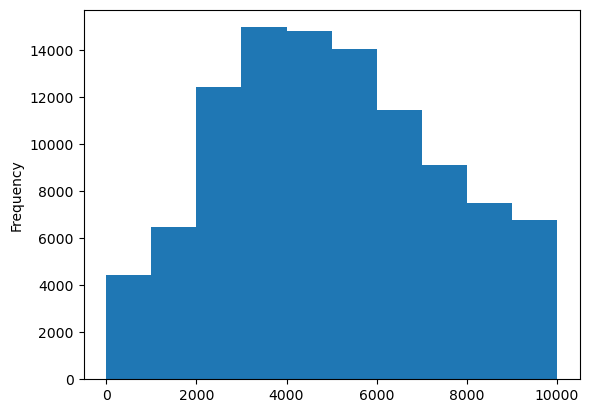

In [5]:
train["MonthlyIncome"][train["MonthlyIncome"] <= 10000].plot(kind='hist');

income = 10e3
while income <= 10e6:
    n_clients = train["MonthlyIncome"][train["MonthlyIncome"] > income].count()
    print(f'MonthlyIncome > {income:,}: {n_clients}, {n_clients/train.shape[0]:.3}%')
    income *= 2

Видим, что имеется несколько очень богатых клиентов, существенно влияющих на среднюю зарплату. Предварительно для восполнения пропусков используем медианное значение

TODO: в дальнейшем можно попробовать, например, kNN

In [6]:
train.fillna({"MonthlyIncome": train["MonthlyIncome"].median()}, inplace=True)

#### `NumberOfDependents`

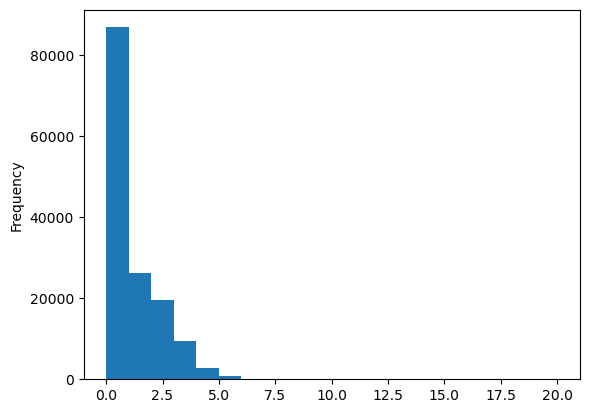

In [7]:
train["NumberOfDependents"].plot(kind='hist', bins=20);

Тут пока тоже заменим на медианное зачение

In [8]:
train["NumberOfDependents"].fillna(train["NumberOfDependents"].median(), inplace=True)

In [9]:
train.isna().sum()

SeriousDlqin2yrs                        0
RevolvingUtilizationOfUnsecuredLines    0
age                                     0
NumberOfTime30-59DaysPastDueNotWorse    0
DebtRatio                               0
MonthlyIncome                           0
NumberOfOpenCreditLinesAndLoans         0
NumberOfTimes90DaysLate                 0
NumberRealEstateLoansOrLines            0
NumberOfTime60-89DaysPastDueNotWorse    0
NumberOfDependents                      0
dtype: int64

Все пропуски устранены.

### Теперь обработаем выбросы

In [10]:
train.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


#### `age`

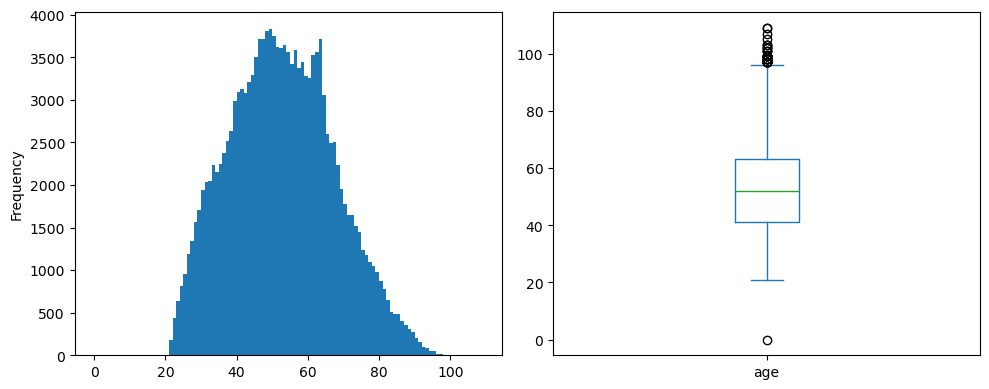

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

train["age"].plot(kind='hist', bins=(train['age'].max() - train['age'].min()), ax=ax1);
train["age"].plot(kind='box', ax=ax2);

plt.tight_layout()
plt.show()

Распределение схоже с нормальным, будем считать выбросы согласно `boxplot` - заменим их на средние значения

In [15]:
age_Q1 = train['age'].quantile(0.25)
age_Q2 = train['age'].quantile(0.50)
age_Q3 = train['age'].quantile(0.75)

IQR = age_Q3 - age_Q1
bottom_fence = age_Q1 - 1.5 * IQR
top_fence = age_Q3 + 1.5 * IQR

mean_age = int(train['age'].mean())
mask = (train['age'] < bottom_fence) | (train['age'] > top_fence)
train.loc[mask, 'age'] = mean_age

In [16]:
print(age_Q1, age_Q2, age_Q3, IQR, top_fence, bottom_fence)

41.0 52.0 63.0 22.0 96.0 8.0


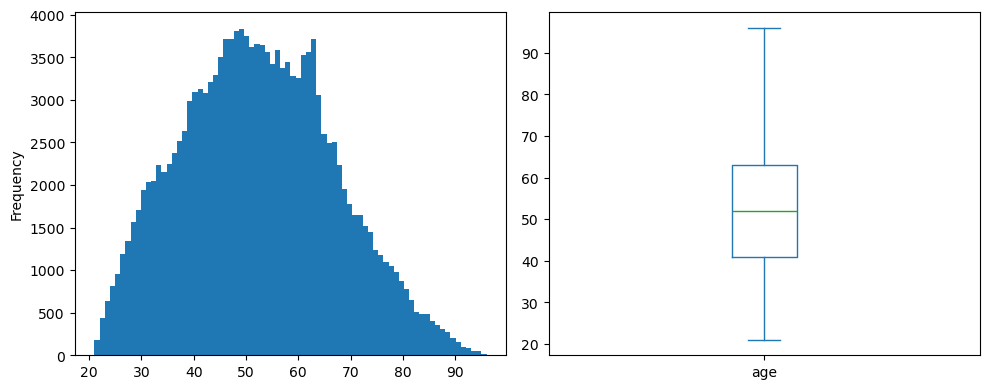

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

train["age"].plot(kind='hist', bins=train['age'].nunique(), ax=ax1);
train["age"].plot(kind='box', ax=ax2);

plt.tight_layout()
plt.show()

#### `NumberOfTime30-59DaysPastDueNotWorse`

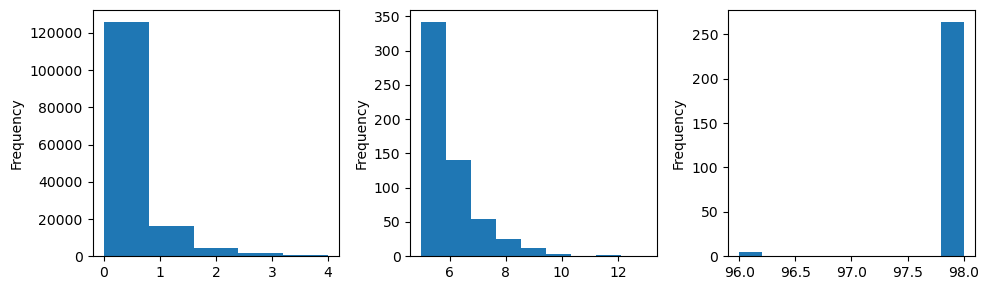

In [18]:
to_4  =  train['NumberOfTime30-59DaysPastDueNotWorse'] <  5
from_5_to_14 = (train['NumberOfTime30-59DaysPastDueNotWorse'] >= 5) & (train['NumberOfTime30-59DaysPastDueNotWorse'] < 14)
from_14      =  train['NumberOfTime30-59DaysPastDueNotWorse'] >= 14

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 3))

train['NumberOfTime30-59DaysPastDueNotWorse'].loc[to_4].plot(kind='hist', ax=ax1, bins=5);
train['NumberOfTime30-59DaysPastDueNotWorse'].loc[from_5_to_14].plot(kind='hist', ax=ax2, bins=9);
train['NumberOfTime30-59DaysPastDueNotWorse'].loc[from_14].plot(kind='hist', ax=ax3);

plt.tight_layout()
plt.show()

print()

Будем считать все значения больше 13 выбросами, заменим их медианным значением

In [19]:
train.loc[from_14, 'NumberOfTime30-59DaysPastDueNotWorse'] = train['NumberOfTime30-59DaysPastDueNotWorse'].median()

#### `DebtRatio`

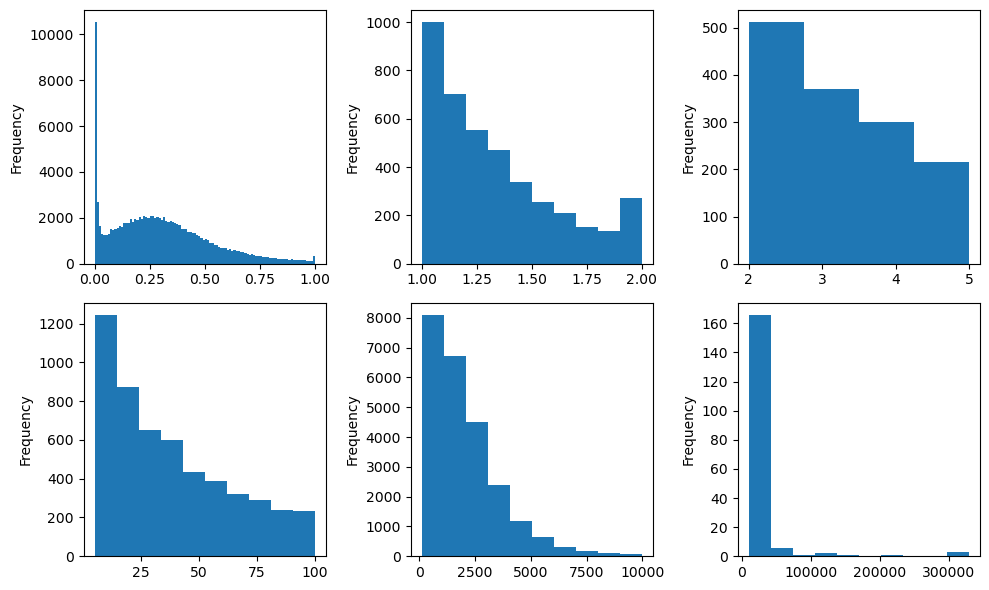

90 quantile: 1267.0


In [20]:
to_1  = (train['DebtRatio'] <= 1)
from_1_to_2  = (train['DebtRatio'] > 1) & (train['DebtRatio'] <= 2)
from_2_to_5 = (train['DebtRatio'] > 2) & (train['DebtRatio'] <= 5)
from_5_to_100 = (train['DebtRatio'] > 5) & (train['DebtRatio'] <= 100)
from_100_to_10000 = (train['DebtRatio'] > 100) & (train['DebtRatio'] <= 10000)
from_10000      =  train['DebtRatio'] > 10000

fig, ((ax1, ax2, ax3), (ax4, ax5, ax6)) = plt.subplots(2, 3, figsize=(10, 6))

train['DebtRatio'].loc[to_1].plot(kind='hist', ax=ax1, bins=100);
train['DebtRatio'].loc[from_1_to_2].plot(kind='hist', ax=ax2, bins=10);
train['DebtRatio'].loc[from_2_to_5].plot(kind='hist', ax=ax3, bins=4);
train['DebtRatio'].loc[from_5_to_100].plot(kind='hist', ax=ax4);
train['DebtRatio'].loc[from_100_to_10000].plot(kind='hist', ax=ax5);
train['DebtRatio'].loc[from_10000].plot(kind='hist', ax=ax6);

plt.tight_layout()
plt.show()

print('90 quantile:', train['DebtRatio'].quantile(0.9))

Видим, что `DebtRatio` достигает огромных значений у значимой части клиентов, разобьем его на промежутки:

In [21]:
train['DebtRatio_binned'] = train['DebtRatio']

labels = ['0%', '0-15%', '15-30%', '30-45%', '45-60%', '60-75%', '75-100%', '100-150%', '150-200%', '200-500%', '500%+']
bins = [-float('inf'), 0.0, 0.15, 0.3, 0.45, 0.6, 0.75, 1.0, 1.5, 2.0, 5.0, float('inf')]

train['DebtRatio_binned'] = pd.cut(train['DebtRatio'], bins=bins, labels=labels)

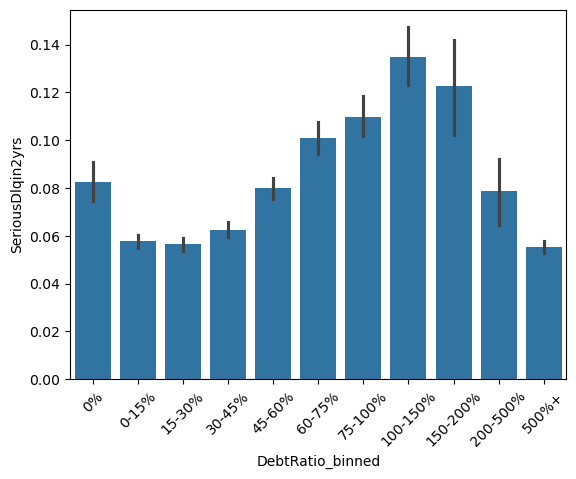

In [22]:
sns.barplot(x=train['DebtRatio_binned'], y=train['SeriousDlqin2yrs']);
plt.xticks(rotation=45)
plt.show()

#### `MonthlyIncome`

In [23]:
MonthlyIncome_quantiles = train['MonthlyIncome'].quantile([0, 0.25, 0.5, 0.75, 0.95, 0.997, 1.0])

MonthlyIncome_quantiles_labels = ['0-25%', '25-50%', '50-75%', '75-95%', '95-99.7%', '99.7-100%']
train['MonthlyIncome_binned'] = pd.cut(train['MonthlyIncome'], bins=MonthlyIncome_quantiles.values,
                                       labels=MonthlyIncome_quantiles_labels, include_lowest=True)

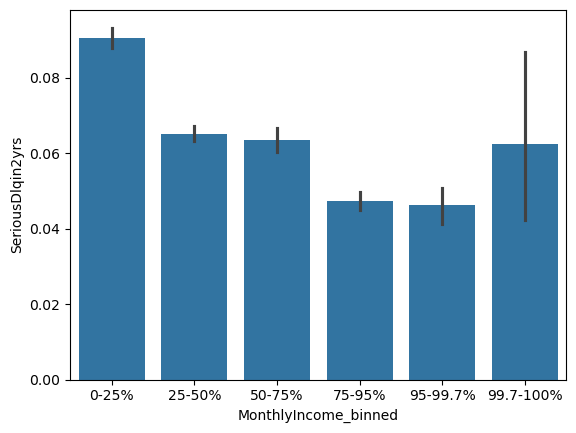

In [24]:
sns.barplot(x=train['MonthlyIncome_binned'], y=train['SeriousDlqin2yrs']);

#### `NumberOfOpenCreditLinesAndLoans`

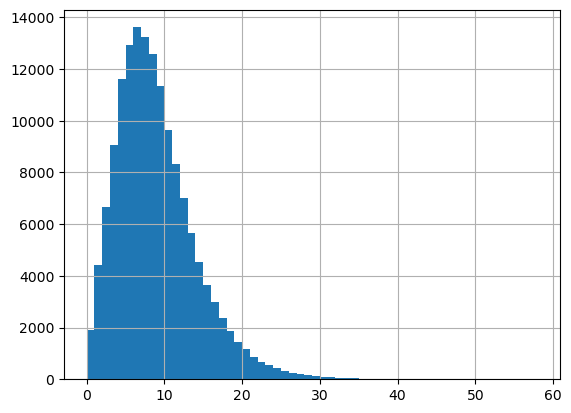

In [25]:
train['NumberOfOpenCreditLinesAndLoans'].hist(bins=58);

In [26]:
train['NumberOfOpenCreditLinesAndLoans'].describe()

count    150000.000000
mean          8.452760
std           5.145951
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          58.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

## Выводы

Дефолт наблюдается у ~6.68% клиентов;

Имеются пропуски в `MonthlyIncome` и `NumberOfDependents`: 19.82% и 2.62% соответственно;

`RevolvingUtilizationOfUnsecuredLines`:

- возростающий монотонный тренд на отрезке \[0, 2\], риск достигает пика в ~0.45
- на интервале \(2, 100\] тренд ломается и риск падает до ~0.3
- затем риск резко обрывается до ~0.05

`age`:

- Наблюдаем пик риска при возрасте около 100 лет, но он, вероятно, обусловлен малой численностью респондентов и случайным всплеском в данных
- Имеется случай возраста "0 лет"
- Молодые более склонны к дефолту
- В целом распределение возраста выглядит нормально :)

`DebtRatio`:

- Достигает максимального значения в 329664.0 с медианой ~ 0.37 (Right-skewed)
- У 99.82% клиентов с `DebtRatio > 50` (у 17.30% пользователей), а также у всех клиентов с `DebtRatio >= 451` (у 14.01% пользователей) доход <= 1 или NaN
- Наибольший риск дефолта у пользователей с `DebtRatio` $\in (1, 2]$, порядка 13%

`MonthlyIncome`:

- 19.82% пропусков, достигает максимального значения в 3008750.0 с медианой ~ 5400.0 (Right-skewed)
- Мода `DebtRatio` с `MonthlyIncome.isna()`:  1995.73
- Мода `DebtRatio` с `MonthlyIncome == 0`: 1500.28
- При DebtRatio > 10 находится 90.04% пропусков
- Распределение количества пропусков и нулевых значений сильно коррелированы